# Bhotekoshi / Trishuli Flood Elevation Profile

Builds the distance-vs-elevation profile of the 26 Aug 2026 Nepal flash flood along `data/bhotekoshi_river.geojson`, using elevation sampled from `data/tiff/dem_2km_buffer.tif`, and annotates it with the cities in `data/cities.geojson` (the ones flagged `flood_profile: true`).

Outputs are written to `elevation_profile/output/`:
- `elevation_profile_static.png` -- final static chart
- `elevation_profile_animation.gif` -- animated version
- `elevation_profile_animation.mp4` -- same, if `ffmpeg` is on PATH
- `river_profile.csv`, `cities_snapped.csv` -- the underlying data, for reuse elsewhere

Re-run top to bottom any time `bhotekoshi_river.geojson`, the DEM, or `cities.geojson` change.

In [1]:
from pathlib import Path

import pandas as pd

import flood_profile as fp
import plotting as pl

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

TITLE = "Nepal Flash Flood"
SUBTITLE = "Bhotekoshi - Trishuli river corridor, 26 August 2026"

## 1. Reconstruct the river line

`data/bhotekoshi_river.geojson` is a set of disconnected line fragments (OSM-traced reaches, plus a few braided side-channels). `merge_river_line` stitches the fragments that share endpoints into a single ordered polyline and drops anything that never reconnects within 5 km (side braids / duplicate channels).

In [2]:
river_line = fp.merge_river_line()
print(f"River line: {len(river_line.coords)} vertices, "
      f"from {river_line.coords[0]} (upstream) to {river_line.coords[-1]} (downstream)")

River line: 2411 vertices, from (85.5122222222223, 28.29305555555561) (upstream) to (83.85122203, 27.35502425) (downstream)


## 2. Sample the DEM along the line

Densify the line every `step_m` metres (in UTM 45N, so spacing is truly metric) and read elevation from `data/tiff/dem_2km_buffer.tif` at each point. A short rolling median smooths pixel-level DEM noise without flattening the real drop in elevation.

6065 samples over 303.2 km, elevation 95-3737 m


<Axes: title={'center': 'Raw sampled profile'}, xlabel='distance_km'>

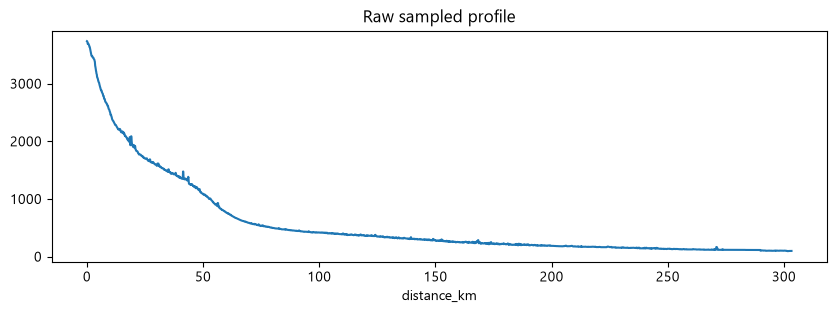

In [3]:
profile = fp.build_profile(river_line, step_m=50)
profile.to_csv(OUTPUT_DIR / "river_profile.csv", index=False)
print(f"{len(profile)} samples over {profile.distance_km.max():.1f} km, "
      f"elevation {profile.elevation_m.min():.0f}-{profile.elevation_m.max():.0f} m")
profile.plot(x="distance_km", y="elevation_m", legend=False, figsize=(10, 3), title="Raw sampled profile")

## 3. Load flood-timeline cities and snap them to the river

`data/cities.geojson` now carries, on every city used in this chart, `flood_profile: true`, `flood_order` (chart left-to-right order), `flood_time` (`HH:MM:SS`, `null` where the arrival time isn't confirmed), and `flood_reached` (`false` only for Chanauli, which sits beyond the confirmed/traced flood extent).

`Seqiong Village`, `Labi Village`, `Timure`, `Syabrubesi`, `Trishuli Bridge` (Trishuli Bazaar), `Bidur`, `Devpur`, `Bharatpur` and `Chanauli` were added from OpenStreetMap (Overpass/Nominatim) since they weren't in the file yet; `Rashuwa`, `Betrawati` and `Malekhu` were matched to the existing Nepali-named entries. `Ghale Gaun`'s coordinates could not be verified against OSM or the project's own bridge-damage data -- it's a rough estimate between Syabrubesi and Betrawati; correct it in `cities.geojson` if you have a better source.

Per your note: a city does **not** need to sit exactly on the river. Each one is projected onto the nearest point on `river_line`, and its distance-along-river and elevation both come from that snapped point / the profile above -- not from the city's own coordinates or its own DEM value.

In [4]:
cities = fp.load_flood_cities()
cities_snapped = fp.snap_cities_to_profile(cities, river_line, profile)
cities_snapped.to_csv(OUTPUT_DIR / "cities_snapped.csv", index=False)

cities_snapped[["name", "flood_order", "distance_km", "elevation_m", "offset_from_river_m", "flood_time", "flood_reached"]]

,name,flood_order,distance_km,elevation_m,offset_from_river_m,flood_time,flood_reached
0,Seqiong Village,1,11.460680,2338.226267,771.388983,08:41:00,True
1,Labi Village,2,14.642228,2161.543635,1006.176930,08:42:00,True
2,Rasuwagadhi (Rashuwa),3,22.006200,1799.000000,102.618007,08:44:00,True
3,Timure,4,25.688910,1703.732998,164.012912,08:46:00,True
4,Syabrubesi,5,37.613059,1425.195001,60.664096,08:50:00,True
5,Ghale Gaun,6,58.098964,815.122946,271.698537,NaN,True
6,Betrawati,7,68.019826,609.000000,155.177667,09:24:00,True
7,Trishuli Bazaar,8,76.084045,529.547025,198.781138,NaN,True
8,Bidur,9,79.519332,500.753283,944.481399,09:38:00,True
9,Malekhu,10,126.520785,349.806921,497.576888,NaN,True


In [5]:
# Flag any city sitting suspiciously far from the mapped river -- likely a
# coordinate worth double-checking in cities.geojson.
far = cities_snapped[cities_snapped.offset_from_river_m > 3000]
if len(far):
    print("Cities more than 3 km from the mapped river line:")
    print(far[["name", "offset_from_river_m"]])
else:
    print("All cities are within 3 km of the mapped river line.")

Cities more than 3 km from the mapped river line:
        name  offset_from_river_m
12  Chanauli          6134.016045


## 4. Static chart

Matches the look of `_extra/elevation_profile_animation.R`'s final frame: grey background profile, an orange/tan "flood has passed here" fill up to the marker, green stems + bold labels for reached cities, grey stems + labels for cities beyond the marker (Chanauli), and a stopwatch frozen at the last confirmed timestamp (Bidur, 09:38:00).

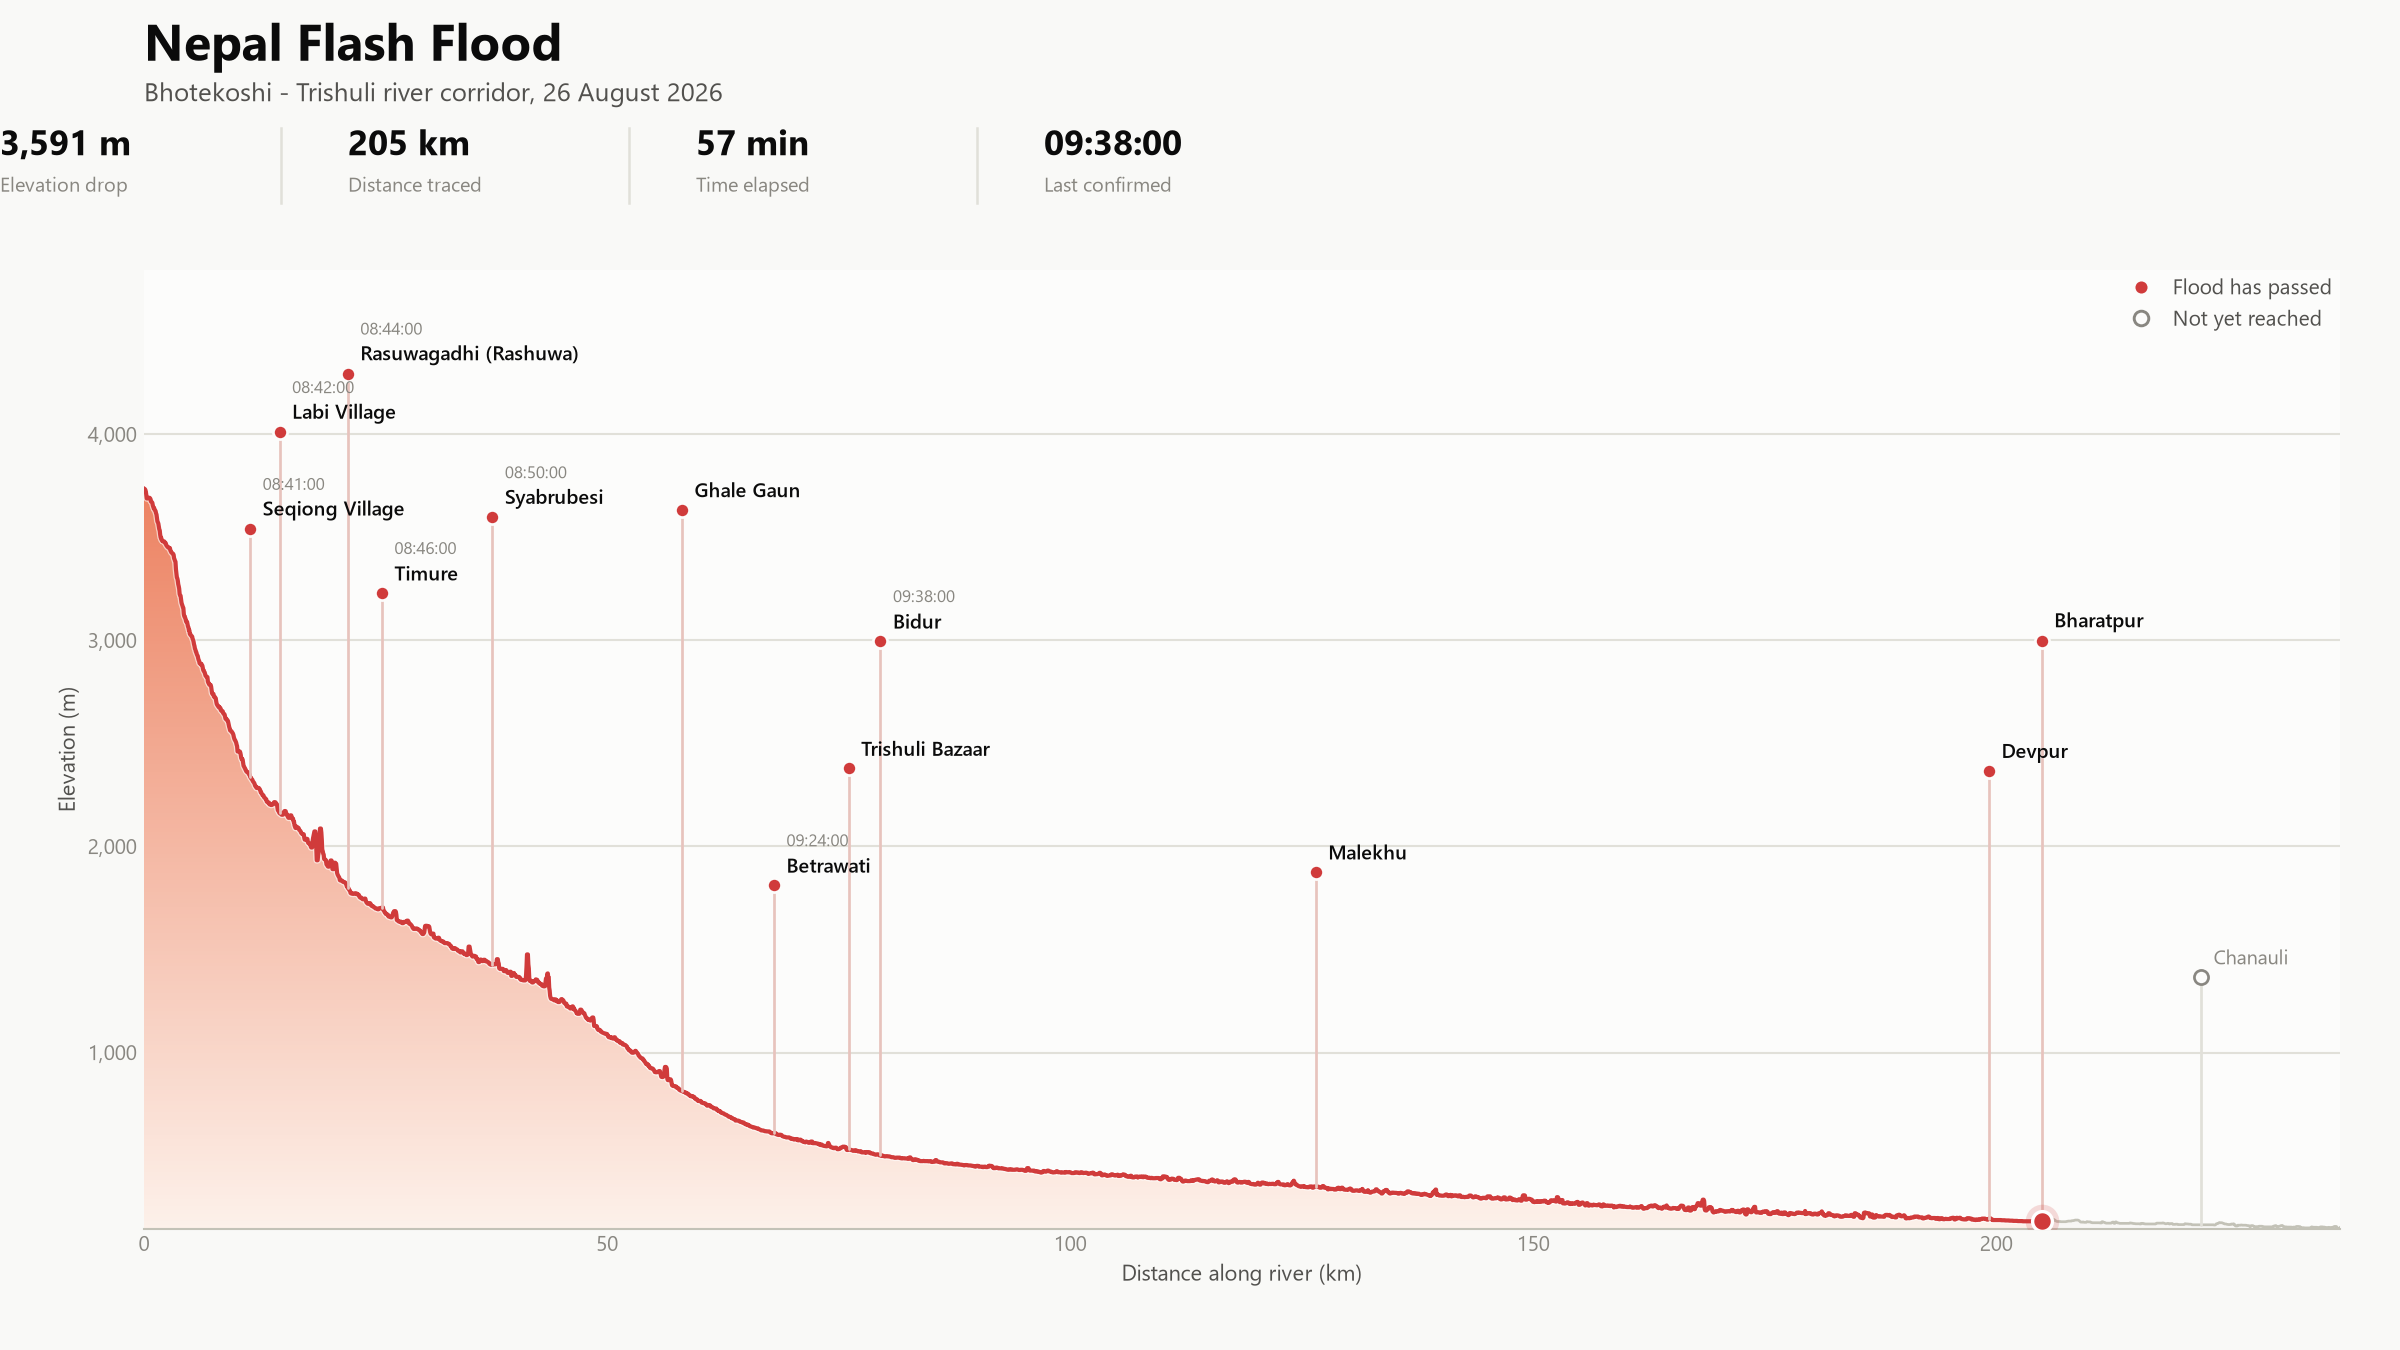

In [6]:
static_path = OUTPUT_DIR / "elevation_profile_static.png"
pl.plot_static(profile, cities_snapped, static_path, TITLE, subtitle=SUBTITLE)

from IPython.display import Image, display
display(Image(filename=str(static_path)))

## 5. Animation

Mirrors the R script's animation logic: the red marker sweeps downstream, the orange fill is revealed behind it, each city's stem/label switches from grey to green/bold the instant the marker passes it, and the stopwatch (interpolated between the known `flood_time` control points, same `approx()`-style logic as the R version) freezes once the marker reaches the last reached city. The marker stops at the furthest `flood_reached: true` city (Bharatpur) -- Chanauli, beyond it, stays pending forever, same as in the reference chart.

This renders a GIF always; it also renders an MP4 if `ffmpeg` is on PATH (install it -- e.g. `winget install ffmpeg` -- and re-run this cell to get one).

Increase `movement_frames`/`fps` for a smoother final render; the values below are a reasonable default. This cell takes a couple of minutes.

In [7]:
gif_path = OUTPUT_DIR / "elevation_profile_animation.gif"
mp4_path = OUTPUT_DIR / "elevation_profile_animation.mp4"

pl.build_animation(
    profile,
    cities_snapped,
    out_gif=gif_path,
    out_mp4=mp4_path,
    title=TITLE,
    subtitle=SUBTITLE,
    fps=12,
    movement_frames=180,
    pause_seconds_known=1.2,
    pause_seconds_unknown=0.4,
)
print("wrote", gif_path)

ffmpeg not found on PATH -- skipped MP4 export (output\elevation_profile_animation.mp4 not written).
wrote output\elevation_profile_animation.gif


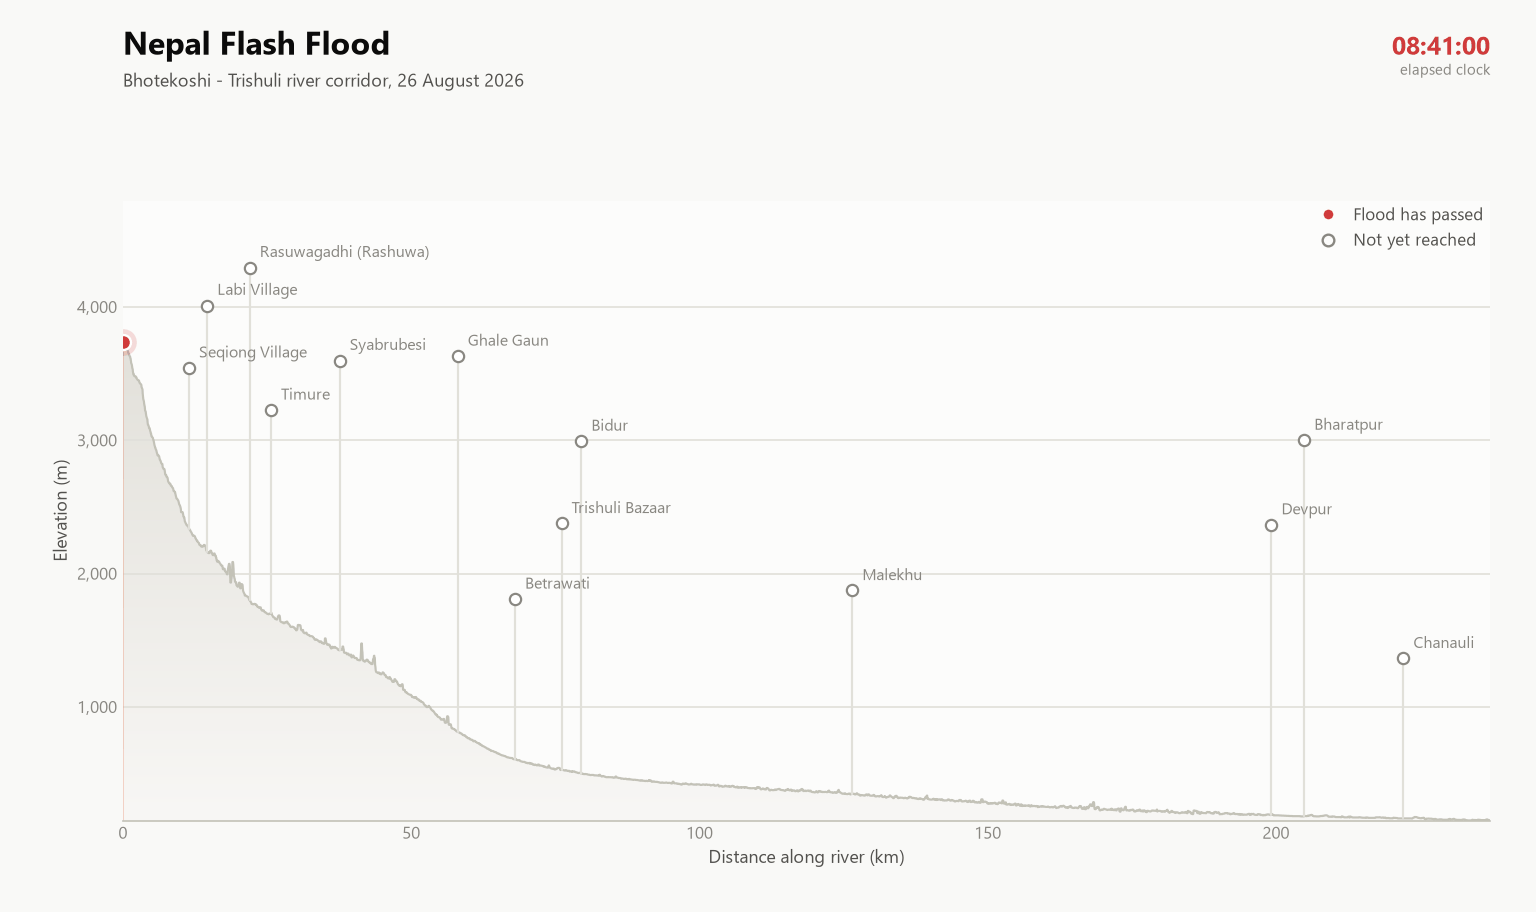

In [8]:
from IPython.display import Image as IPImage, display as ip_display

ip_display(IPImage(filename=str(gif_path)))